# Instructions

This notebook extends `LocationTracking_BatchProcess.ipynb` by adding a per-video reference-image workflow before batch processing.

Use this notebook when the default median reference frame should be reviewed for each video separately and the reference-frame sampling parameters should be editable on a per-video basis before tracking the full batch.

# 1. Load Necessary Packages
The following code loads necessary packages and need not be changed by the user.

In [14]:
%load_ext autoreload
%autoreload 2
import ast
import os
from pathlib import Path

import math
import matplotlib.pyplot as plt
import cv2
import holoviews as hv
import numpy as np
import pandas as pd
from tqdm import tqdm

import LocationTracking_Functions as lt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. User Defines Batch Processing Directory and Settings
Below, options are set by user for batch processing of videos. If you are unfamiliar with these settings, please see `LocationTracking_Individual.ipynb`.

In [2]:
# define video parameters
video_dict = {
    'dpath'        : "/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/YZ/Miniscope_data/Miniscope_data/Linear_track/BehavCamConcactenated_311/rotated_and_cropped_avi/",
    'ftype'        : 'avi',
    'start'        : 0,
    'end'          : None,
    'region_names' : None,  # ['Left','Right']
    'dsmpl'        : 1,
    'stretch'      : dict(width=1, height=1)
}

# define parameters for location tracking
tracking_params = {
    'loc_thresh'    : 90.5,
    'use_window'    : True,
    'window_size'   : 200,
    'window_weight' : .95,
    'method'        : 'abs',
    'rmv_wire'      : True,
    'wire_krn'      : 10
}

# set bin_dict = None if only overall session average is desired
bin_dict = None

# load folder with files
video_dict = lt.Batch_LoadFiles(video_dict)
video_dict['FileNames']


['m311_04022025_19_15_29_concactenatedbehavCam00_behavCam20_rotated_cropped.avi',
 'm311_04032025_15_39_01_concactenatedbehavCam00_behavCam20_rotated_cropped.avi',
 'm311_04042025_21_05_03_concactenatedbehavCam00_behavCam20_rotated_cropped.avi',
 'm311_04082025_16_21_42_concactenatedbehavCam00_behavCam20_rotated_cropped.avi',
 'm311_04092025_15_28_20_concactenatedbehavCam00_behavCam20_rotated_cropped.avi',
 'm311_04102025_16_39_41_concactenatedbehavCam00_behavCam20_rotated_cropped.avi']

# 3. (Optional) Crop Image if Desired
To crop video frame, after running code below, select box selection tool below image (square with a plus sign). To start drawing region to be included in analysis, double click image. Double click again to finalize region. If you decide to change region, it is best to rerun this cell and subsequent steps. Note that this is done based upon first video in folder.

In [ ]:
%%output size=100

img_crp, video_dict = lt.LoadAndCrop(video_dict, cropmethod='Box', fstfile=True)
img_crp


# 4. (Optional) Mask Internal Regions
The following code is used to exclude internal portion of image from the field of view. After running cell below, draw regions to be excluded. To start drawing a region, double click on image. Single click to add a vertex. Double click to close polygon. If you mess up it's easiest to re-run cell.

In [ ]:
%%output size=100

img_mask, video_dict['mask'] = lt.Mask_select(video_dict, fstfile=True)
img_mask


# 5. (Optional) Define Regions of Interest
After running cell below, draw regions of interest on presented image in the order you provided them. To start drawing a region, double click on image. Single click to add a vertex. Double click to close polygon. If you mess up it's easiest to re-run cell. Note that this is done based upon first video in folder.

In [ ]:
%%output size=100

video_dict['reference'], img_ref = lt.Reference(video_dict, fstfile=True, num_frames=50)
img_roi, video_dict['roi_stream'] = lt.ROI_plot(video_dict)
img_roi


# 6. (Optional) Define Scale for Distance Calculations

In [3]:
%%output size=500

video_dict['reference'], img_ref = lt.Reference(video_dict, fstfile=True, num_frames=100)
img_scl, video_dict['scale'] = lt.DistanceTool(video_dict)
img_scl


:DynamicMap   []
   :Overlay
      .Image.I  :Image   [x,y]   (z)
      .Points.I :Points   [x,y]
      .Labels.I :Labels   [x,y]   (Label)

In [4]:
distance = 6
scale = 'cm'

video_dict['scale'] = lt.setScale(distance, scale, video_dict['scale'])


# 7. Build Per-Video Reference Configuration
The next cells create a per-video table of reference-frame settings, preview the default median reference image for each video, and allow those settings to be edited before running the batch analysis.

In [15]:
def build_reference_config(video_dict, default_num_frames=200, default_frame_start=None, default_frame_end=None):
    rows = []
    for file_name in video_dict['FileNames']:
        rows.append({
            'file_name': file_name,
            'ref_num_frames': int(default_num_frames),
            'ref_frame_start': default_frame_start,
            'ref_frame_end': default_frame_end,
            'frames_list': None,
            'enabled': True,
            'notes': ''
        })
    return pd.DataFrame(rows)


def parse_frames_list(value):
    if value is None:
        return None
    if isinstance(value, float) and pd.isna(value):
        return None
    if isinstance(value, str):
        stripped = value.strip()
        if stripped == '':
            return None
        value = ast.literal_eval(stripped)

    if isinstance(value, np.ndarray):
        value = value.tolist()
    elif not isinstance(value, (list, tuple)):
        value = [value]

    frames = []
    for frame in value:
        if frame is None:
            continue
        if isinstance(frame, float) and pd.isna(frame):
            continue
        frames.append(int(frame))

    return frames or None


def reference_frames_from_row(video_dict_local, row):
    start_default = int(video_dict_local['start']) if video_dict_local['start'] is not None else 0

    cap = cv2.VideoCapture(video_dict_local['fpath'])
    cap_max = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    end_default = int(video_dict_local['end']) if video_dict_local['end'] is not None else max(cap_max - 1, start_default)

    frames_list = parse_frames_list(getattr(row, 'frames_list', None))
    if frames_list is not None:
        cleaned = sorted({max(start_default, min(int(frame), max(cap_max - 1, start_default))) for frame in frames_list})
        return np.array(cleaned, dtype=int)

    start = start_default if pd.isna(row.ref_frame_start) else int(row.ref_frame_start)
    end = end_default if pd.isna(row.ref_frame_end) else int(row.ref_frame_end)

    start = max(start_default, start)
    end = max(start, min(end, max(cap_max - 1, start)))

    if pd.isna(row.ref_frame_start) and pd.isna(row.ref_frame_end):
        return None

    num_frames = max(1, int(row.ref_num_frames))
    if num_frames == 1:
        return np.array([start], dtype=int)

    return np.linspace(start=start, stop=end, num=num_frames, dtype=int)


def preview_reference_images(video_dict, reference_config_df):
    images = []
    rows = []

    enabled_df = reference_config_df.loc[reference_config_df['enabled']].reset_index(drop=True)
    for row in tqdm(enabled_df.itertuples(index=False), total=len(enabled_df), desc='Reference previews'):
        video_dict_local = dict(video_dict)
        video_dict_local['file'] = row.file_name
        video_dict_local['fpath'] = os.path.join(os.path.normpath(video_dict_local['dpath']), row.file_name)

        frames = reference_frames_from_row(video_dict_local, row)
        reference_num_frames = len(frames) if frames is not None else max(1, int(row.ref_num_frames))
        video_dict_local['reference'], img_ref = lt.Reference(
            video_dict_local,
            num_frames=reference_num_frames,
            frames=frames
        )

        frame_desc = 'full video' if frames is None else (str(frames.tolist()) if len(frames) <= 10 else f"{int(frames[0])}-{int(frames[-1])} ({len(frames)} frames)")
        title = f"{row.file_name}\nnum_frames={reference_num_frames} | frames={frame_desc}"
        images.append(img_ref.opts(title=title))

        rows.append({
            'file_name': row.file_name,
            'ref_num_frames': reference_num_frames,
            'ref_frame_start': row.ref_frame_start,
            'ref_frame_end': row.ref_frame_end,
            'frames_list': getattr(row, 'frames_list', None),
            'frame_range_used': frame_desc
        })

    layout = hv.Layout(images) if images else None
    return pd.DataFrame(rows), layout

def preview_reference_images_matplotlib(video_dict, reference_config_df, ncols=2):
    enabled_df = reference_config_df.loc[reference_config_df["enabled"]].reset_index(drop=True)

    previews = []
    for row in tqdm(enabled_df.itertuples(index=False), total=len(enabled_df), desc="Reference previews"):
        video_dict_local = dict(video_dict)
        video_dict_local["file"] = row.file_name
        video_dict_local["fpath"] = os.path.join(os.path.normpath(video_dict_local["dpath"]), row.file_name)

        frames = reference_frames_from_row(video_dict_local, row)
        reference_num_frames = len(frames) if frames is not None else max(1, int(row.ref_num_frames))
        video_dict_local["reference"], img_ref = lt.Reference(
            video_dict_local,
            num_frames=reference_num_frames,
            frames=frames
        )

        frame_desc = "full video" if frames is None else (str(frames.tolist()) if len(frames) <= 10 else f"{int(frames[0])}-{int(frames[-1])} ({len(frames)} frames)")
        previews.append({
            "file_name": row.file_name,
            "image": video_dict_local["reference"],
            "frame_range_used": frame_desc,
            "ref_num_frames": reference_num_frames,
        })

    n = len(previews)
    if n == 0:
        print("No enabled videos to preview.")
        return previews

    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax, preview in zip(axes, previews):
        ax.imshow(preview["image"], cmap="gray")
        ax.set_title(
            f"{preview['file_name']}\n"
            f"num_frames={preview['ref_num_frames']} | range={preview['frame_range_used']}",
            fontsize=10
        )
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return previews


def build_validation_display_dict(video_dict_local, fps=240, resize=None, start=0, stop=None, save_video=True):
    cap = cv2.VideoCapture(video_dict_local['fpath'])
    num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    start = max(0, int(start))
    stop = num_frames if stop is None else min(num_frames, int(stop))
    stop = max(start + 1, stop)

    display_dict = {
        'start': start,
        'stop': stop,
        'fps': int(fps),
        'resize': resize,
        'save_video': bool(save_video)
    }
    return display_dict, num_frames


def validation_video_dir(video_dict_local):
    out_dir = os.path.join(os.path.normpath(video_dict_local['dpath']), 'validation_videos')
    os.makedirs(out_dir, exist_ok=True)
    return out_dir


def default_validation_output_path(video_dict_local):
    return os.path.join(
        validation_video_dir(video_dict_local),
        os.path.splitext(video_dict_local['file'])[0] + '_ValidationVideo.avi'
    )


def unique_validation_output_path(video_dict_local, output_path=None):
    base_path = output_path or default_validation_output_path(video_dict_local)
    root, ext = os.path.splitext(base_path)
    candidate = base_path
    version = 2

    while os.path.exists(candidate):
        candidate = f'{root}_v{version}{ext}'
        version += 1

    return candidate


def playvideo_temp_output_path(video_dict_local):
    return os.path.join(
        os.path.normpath(video_dict_local['dpath']),
        video_dict_local['file'].rstrip('.avi') + 'video_output.avi'
    )


def load_saved_location_output(video_dict_local):
    location_path = os.path.splitext(video_dict_local['fpath'])[0] + '_LocationOutput.csv'
    if not os.path.exists(location_path):
        raise FileNotFoundError(
            f'Location output not found for {video_dict_local["file"]}: {location_path}'
        )
    return pd.read_csv(location_path), location_path


def create_validation_video_for_file(
    video_dict,
    file_name,
    location=None,
    location_path=None,
    fps=240,
    resize=None,
    start=0,
    stop=None,
    save_video=True,
    output_path=None,
    display_video=True,
):
    video_dict_local = dict(video_dict)
    video_dict_local['file'] = file_name
    video_dict_local['fpath'] = os.path.join(os.path.normpath(video_dict_local['dpath']), file_name)
    video_dict_local.setdefault('crop', None)

    if location is None:
        if location_path is None:
            location, location_path = load_saved_location_output(video_dict_local)
        else:
            location = pd.read_csv(location_path)
    elif location_path is None:
        location_path = os.path.splitext(video_dict_local['fpath'])[0] + '_LocationOutput.csv'

    display_dict, num_frames = build_validation_display_dict(
        video_dict_local,
        fps=fps,
        resize=resize,
        start=start,
        stop=stop,
        save_video=save_video,
    )

    if display_video:
        lt.PlayVideo(video_dict_local, display_dict, location)
    else:
        original_display_image = lt.display_image
        try:
            lt.display_image = lambda frame, fps, resize: None
            lt.PlayVideo(video_dict_local, display_dict, location)
        finally:
            lt.display_image = original_display_image

    raw_output_path = playvideo_temp_output_path(video_dict_local)
    final_output_path = unique_validation_output_path(video_dict_local, output_path=output_path) if save_video else None

    if save_video:
        if os.path.exists(raw_output_path):
            if os.path.abspath(raw_output_path) != os.path.abspath(final_output_path):
                os.replace(raw_output_path, final_output_path)
        else:
            final_output_path = None

    return {
        'file_name': file_name,
        'location_path': location_path,
        'validation_start': display_dict['start'],
        'validation_stop': display_dict['stop'],
        'validation_fps': display_dict['fps'],
        'num_frames': num_frames,
        'saved_video_path': final_output_path,
        'display_video': bool(display_video),
    }


def create_validation_video_from_file(
    video_path,
    location_csv_path,
    crop=None,
    dsmpl=1,
    fps=240,
    resize=None,
    start=0,
    stop=None,
    save_video=True,
    output_path=None,
    display_video=True,
):
    video_path = os.path.abspath(video_path)
    location_csv_path = os.path.abspath(location_csv_path)

    video_dict = {
        'dpath': os.path.dirname(video_path),
        'dsmpl': dsmpl,
        'crop': crop,
    }

    return create_validation_video_for_file(
        video_dict,
        os.path.basename(video_path),
        location=None,
        location_path=location_csv_path,
        fps=fps,
        resize=resize,
        start=start,
        stop=stop,
        save_video=save_video,
        output_path=output_path,
        display_video=display_video,
    )


def create_validation_videos(
    video_dict,
    reference_config_df,
    location_outputs=None,
    fps=240,
    resize=None,
    start=0,
    stop=None,
    save_video=True,
    display_video=True,
):
    rows = []
    enabled_df = reference_config_df.loc[reference_config_df['enabled']].reset_index(drop=True)

    for row in tqdm(enabled_df.itertuples(index=False), total=len(enabled_df), desc='Validation videos'):
        location = None if location_outputs is None else location_outputs.get(row.file_name)
        rows.append(
            create_validation_video_for_file(
                video_dict,
                row.file_name,
                location=location,
                fps=fps,
                resize=resize,
                start=start,
                stop=stop,
                save_video=save_video,
                display_video=display_video,
            )
        )

    return pd.DataFrame(rows)


def Batch_Process_indivReference(video_dict, tracking_params, bin_dict, reference_config_df, accept_p_frames=False, summary_filename='BatchSummary_indivReference.csv'):
    images = []
    summary_parts = []
    location_outputs = {}

    enabled_df = reference_config_df.loc[reference_config_df['enabled']].reset_index(drop=True)
    for row in tqdm(enabled_df.itertuples(index=False), total=len(enabled_df), desc='Batch files'):
        print(f'Processing File: {row.file_name}')

        video_dict_local = dict(video_dict)
        video_dict_local['file'] = row.file_name
        video_dict_local['fpath'] = os.path.join(os.path.normpath(video_dict_local['dpath']), row.file_name)

        cap = cv2.VideoCapture(video_dict_local['fpath'])
        cap_max = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        print(f'total frames: {cap_max}')
        print(f'nominal fps: {cap.get(cv2.CAP_PROP_FPS)}')
        print('dimensions (h x w): {h},{w}'.format(
            h=int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
            w=int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        ))
        if accept_p_frames is False:
            lt.check_p_frames(cap)
        cap.release()

        frames = reference_frames_from_row(video_dict_local, row)
        reference_num_frames = len(frames) if frames is not None else max(1, int(row.ref_num_frames))
        video_dict_local['reference'], reference_image = lt.Reference(
            video_dict_local,
            num_frames=reference_num_frames,
            frames=frames
        )

        location = lt.TrackLocation(video_dict_local, tracking_params)
        location_outputs[row.file_name] = location.copy()
        location.to_csv(os.path.splitext(video_dict_local['fpath'])[0] + '_LocationOutput.csv', index=False)

        file_summary = lt.Summarize_Location(location, video_dict_local, bin_dict=bin_dict)
        file_summary['ref_num_frames'] = reference_num_frames
        file_summary['ref_frame_start'] = row.ref_frame_start
        file_summary['ref_frame_end'] = row.ref_frame_end
        file_summary['frames_list'] = str(parse_frames_list(getattr(row, 'frames_list', None)))
        summary_parts.append(file_summary)

        trace = lt.showtrace(video_dict_local, location)
        heatmap = lt.Heatmap(video_dict_local, location, sigma=None)
        images = images + [
            reference_image.opts(title=f'{row.file_name} reference'),
            trace.opts(title=f'{row.file_name} trace'),
            heatmap.opts(title=f'{row.file_name} heatmap')
        ]

    summary_all = pd.concat(summary_parts, sort=False, ignore_index=True) if summary_parts else pd.DataFrame()
    sum_pathout = os.path.join(os.path.normpath(video_dict['dpath']), summary_filename)
    summary_all.to_csv(sum_pathout, index=False)

    layout = hv.Layout(images) if images else None
    return summary_all, layout, location_outputs




In [6]:
reference_config_df = build_reference_config(
    video_dict,
    default_num_frames=200,
    default_frame_start=None,
    default_frame_end=None,
)

reference_config_df


,file_name,ref_num_frames,ref_frame_start,ref_frame_end,enabled,notes
0,m311_04022025_19_15_29_concactenatedbehavCam00...,200,None,None,True,
1,m311_04032025_15_39_01_concactenatedbehavCam00...,200,None,None,True,
2,m311_04042025_21_05_03_concactenatedbehavCam00...,200,None,None,True,
3,m311_04082025_16_21_42_concactenatedbehavCam00...,200,None,None,True,
4,m311_04092025_15_28_20_concactenatedbehavCam00...,200,None,None,True,
5,m311_04102025_16_39_41_concactenatedbehavCam00...,200,None,None,True,


# 8. Edit Per-Video Reference Parameters
Update `reference_config_df` as needed before running the preview and batch processing cells.

Example changes:
- `reference_config_df.loc[0, 'ref_num_frames'] = 300`
- `reference_config_df.loc[0, ['ref_frame_start', 'ref_frame_end']] = [500, 5000]`
- `reference_config_df.loc[1, 'frames_list'] = [1, 40, 50]`
- `reference_config_df.loc[0, 'enabled'] = False`

If `frames_list` is provided for a video, it overrides the random/frame-range reference sampling for that video only.

In [10]:
reference_config_df


,file_name,ref_num_frames,ref_frame_start,ref_frame_end,enabled,notes
0,m311_04022025_19_15_29_concactenatedbehavCam00...,200,None,None,True,
1,m311_04032025_15_39_01_concactenatedbehavCam00...,200,None,None,True,
2,m311_04042025_21_05_03_concactenatedbehavCam00...,200,None,None,True,
3,m311_04082025_16_21_42_concactenatedbehavCam00...,200,None,None,True,
4,m311_04092025_15_28_20_concactenatedbehavCam00...,200,None,None,True,
5,m311_04102025_16_39_41_concactenatedbehavCam00...,200,None,None,True,


# 9. Preview Default / Updated Median Reference Images
This cell displays the reference image that will be used for each enabled video under the current per-video settings.

Reference previews: 100%|█████████████████████████| 6/6 [00:22<00:00,  3.69s/it]


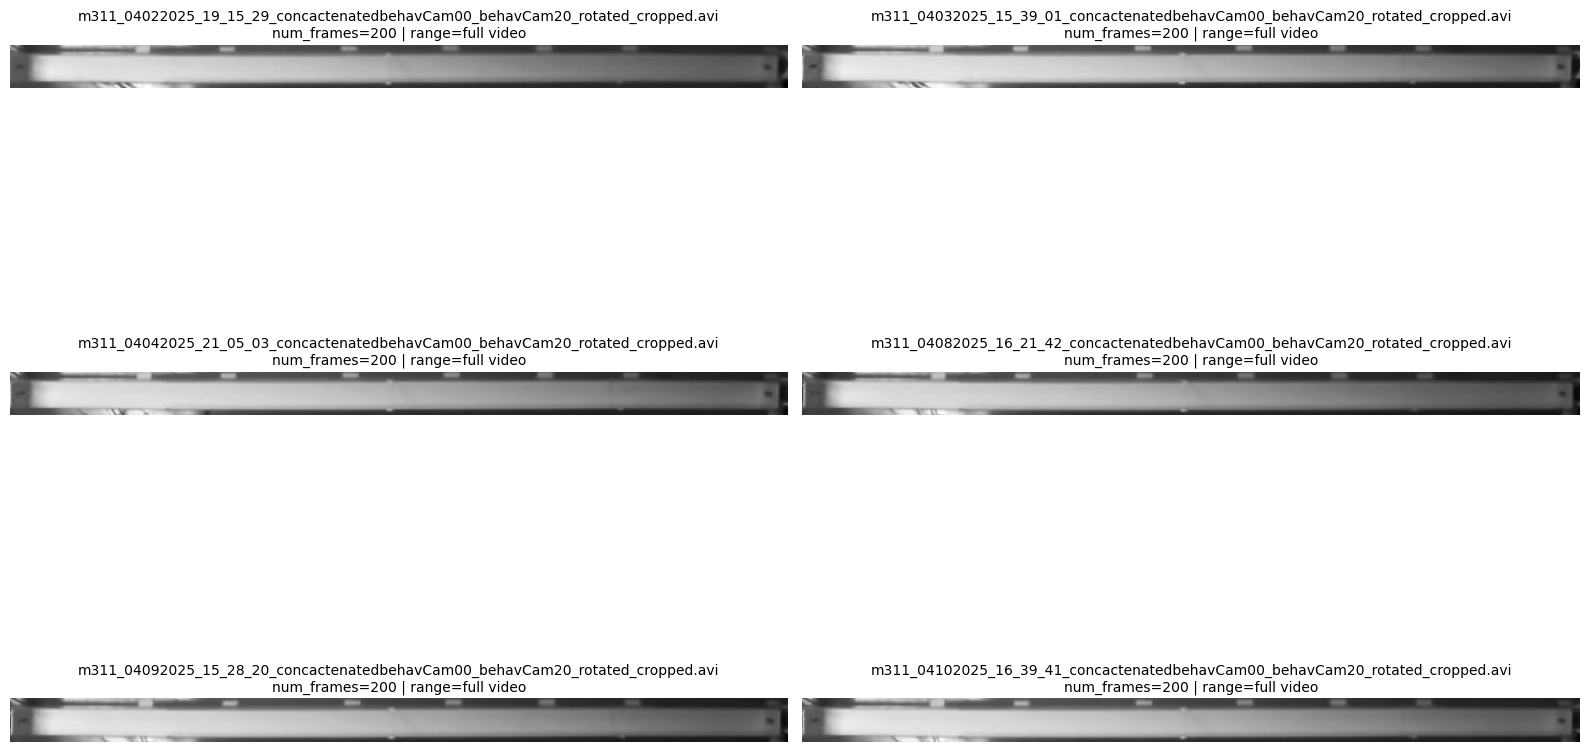

In [16]:
reference_previews = preview_reference_images_matplotlib(video_dict, reference_config_df, ncols=2)


# 10. Perform Batch Processing and Display Traces from Each Session
This batch run uses the per-video reference settings currently stored in `reference_config_df`.

In [17]:
%%opts Layout [shared_axes=False]
%%output size=100

summary, images, location_outputs = Batch_Process_indivReference(
    video_dict,
    tracking_params,
    bin_dict,
    reference_config_df,
    accept_p_frames=False,
    summary_filename='BatchSummary_indivReference.csv'
)

images.cols(3)


Batch files:   0%|                                        | 0/6 [00:00<?, ?it/s]

Processing File: m311_04022025_19_15_29_concactenatedbehavCam00_behavCam20_rotated_cropped.avi
total frames: 20576
nominal fps: 60.0
dimensions (h x w): 38,678



100%|███████████████████████████████████| 20576/20576 [00:14<00:00, 1453.21it/s]


total frames processed: 20576



Batch files:  17%|█████▎                          | 1/6 [00:18<01:32, 18.58s/it]

...

Processing File: m311_04102025_16_39_41_concactenatedbehavCam00_behavCam20_rotated_cropped.avi
total frames: 20569
nominal fps: 60.0
dimensions (h x w): 38,678



100%|███████████████████████████████████| 20569/20569 [00:14<00:00, 1463.20it/s]


total frames processed: 20569



Batch files: 100%|████████████████████████████████| 6/6 [01:43<00:00, 17.28s/it]


:Layout
   .Image.I     :Image   [x,y]   (z)
   .Overlay.I   :Overlay
      .Image.I   :Image   [x,y]   (z)
      .Scatter.I :Scatter   [x]   (y)
   .Image.II    :Image   [x,y]   (z)
   .Image.III   :Image   [x,y]   (z)
   .Overlay.II  :Overlay
      .Image.I   :Image   [x,y]   (z)
      .Scatter.I :Scatter   [x]   (y)
   .Image.IV    :Image   [x,y]   (z)
   .Image.V     :Image   [x,y]   (z)
   .Overlay.III :Overlay
      .Image.I   :Image   [x,y]   (z)
      .Scatter.I :Scatter   [x]   (y)
   .Image.VI    :Image   [x,y]   (z)
   .Image.VII   :Image   [x,y]   (z)
   .Overlay.IV  :Overlay
      .Image.I   :Image   [x,y]   (z)
      .Scatter.I :Scatter   [x]   (y)
   .Image.VIII  :Image   [x,y]   (z)
   .Image.IX    :Image   [x,y]   (z)
   .Overlay.V   :Overlay
      .Image.I   :Image   [x,y]   (z)
      .Scatter.I :Scatter   [x]   (y)
   .Image.X     :Image   [x,y]   (z)
   .Image.XI    :Image   [x,y]   (z)
   .Overlay.VI  :Overlay
      .Image.I   :Image   [x,y]   (z)
      .Scatter.I :Scatter   [x]   (y)
   .Image.XII   :Image   [x,y]   (z)

# 11. Create Validation Videos
Create review videos with the ezTrack-estimated mouse position overlaid on each enabled source video. Saved outputs go into a `validation_videos/` subfolder and auto-version on reruns.

In [18]:
validation_results = create_validation_videos(
    video_dict,
    reference_config_df,
    location_outputs=location_outputs,
    fps=240,
    resize=None,
    start=0,
    stop=None,
    save_video=True,
    display_video=False,
)

validation_results


Validation videos:   0%|                                  | 0/6 [00:00<?, ?it/s]


KeyError: 'crop'